Assignment 05

Bob has started his own mobile company. He wants to give tough fight to big companies
like Apple, Samsung etc. He does not know how to estimate price of mobiles his company
creates. In this competitive mobile phone market, you cannot simply assume things. To
solve this problem, he collects sales data of mobile phones of various companies. Bob
wants to find out some relation between features of a mobile phone (eg:- RAM, Internal
Memory etc) and its selling price. But he is not so good at Machine Learning. Create an
artificial neural network-based classifier to help Bob. Data and class labels are available
in mobile_price_classification.csv file. Use price_range column as label and remaining
columns as data.
Also do the hyperparmeter tuning.


Load Dataset

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("/content/mobile_price_classification.csv")
df = data.copy()   #copy of original dataset

In [4]:
df.head(5)

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

In [6]:
df.describe()

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


Preprocessing

Check for Duplicates and Missing data

In [7]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
#Check for Missing values
df.isna().mean()*100

,0
battery_power,0.0
bluetooth,0.0
clock_speed,0.0
dual_sim,0.0
front_cam,0.0
4G,0.0
int_memory,0.0
m_dep,0.0
mobile_wt,0.0
n_cores,0.0


No Duplicates or missing data in dataset

Divide numerical columns and categorical columns

In [9]:
num_cols = df.select_dtypes(exclude="object").columns
print("the numerical columns are:",num_cols)

the numerical columns are: Index(['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_cam',
       '4G', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'primary_camera',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


Outlier Detection

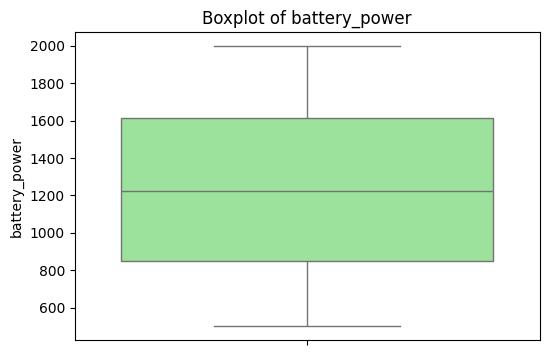

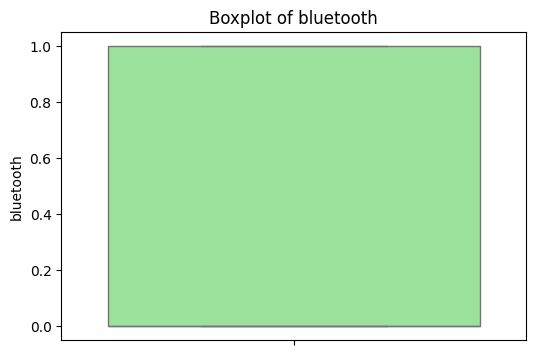

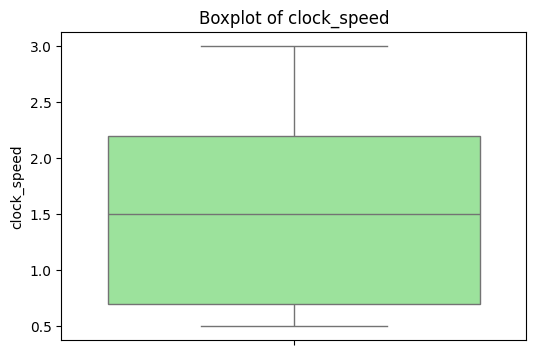

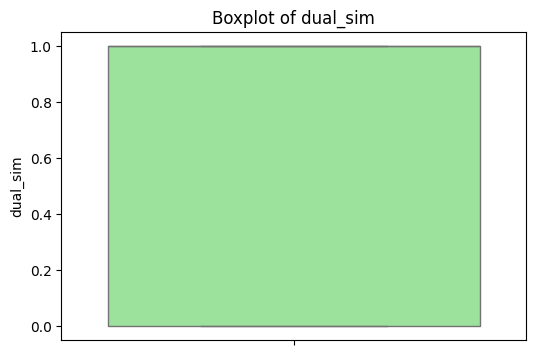

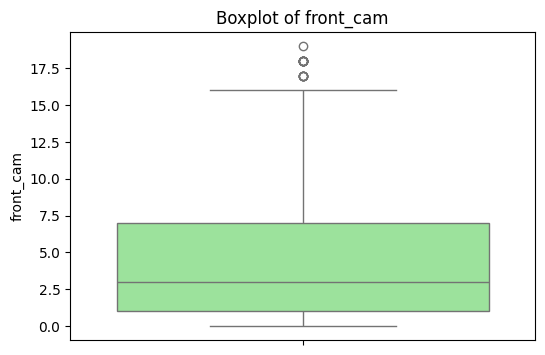

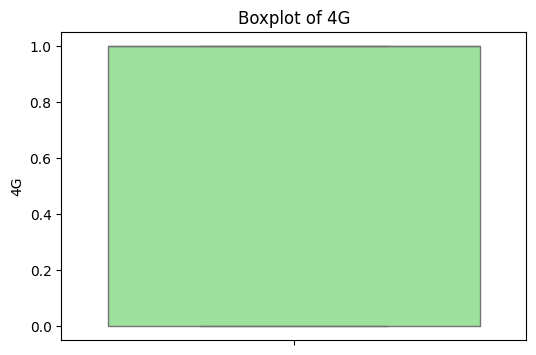

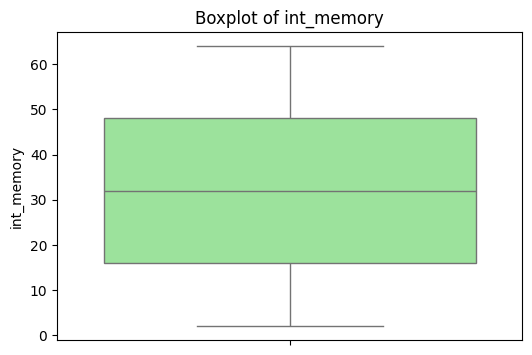

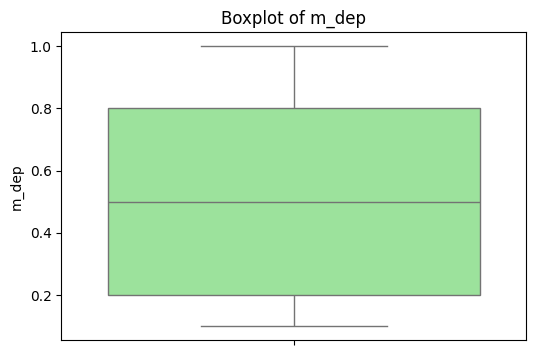

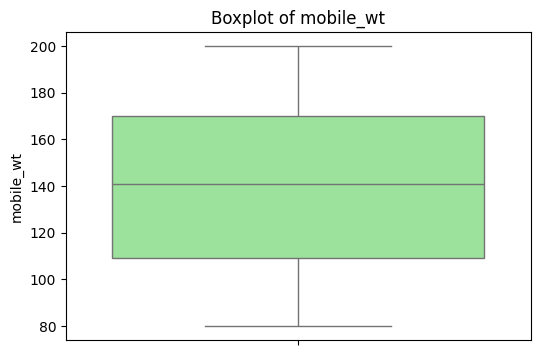

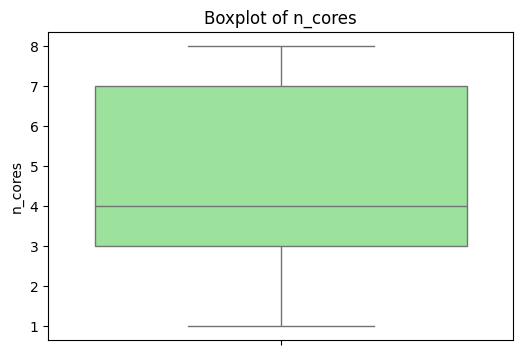

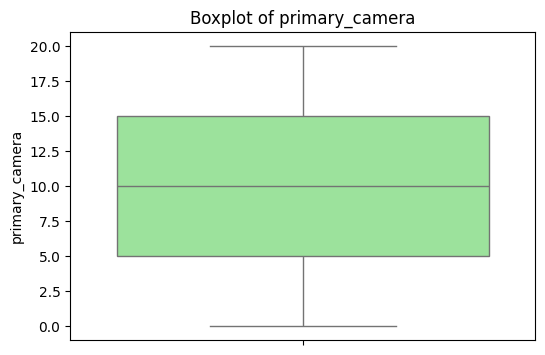

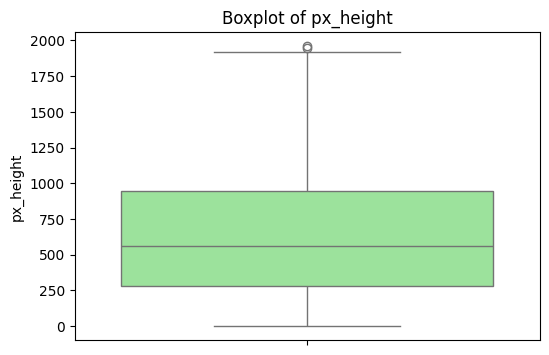

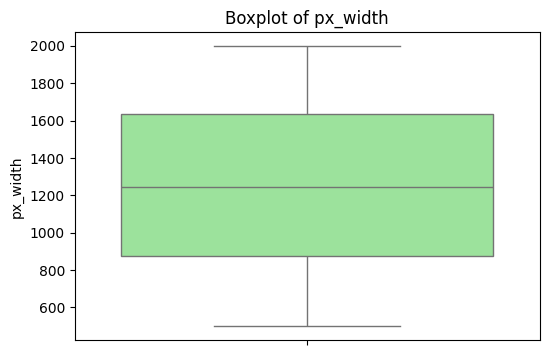

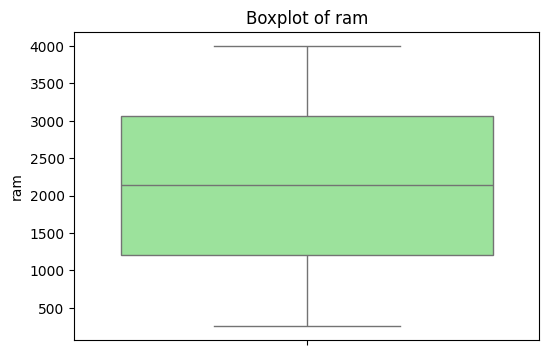

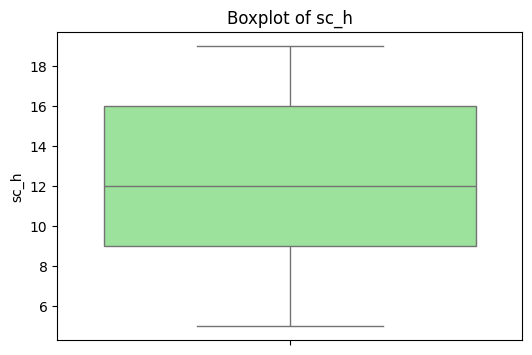

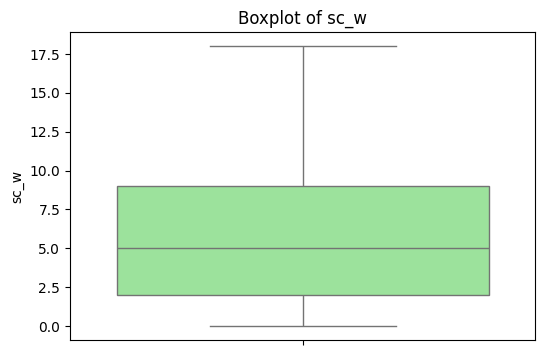

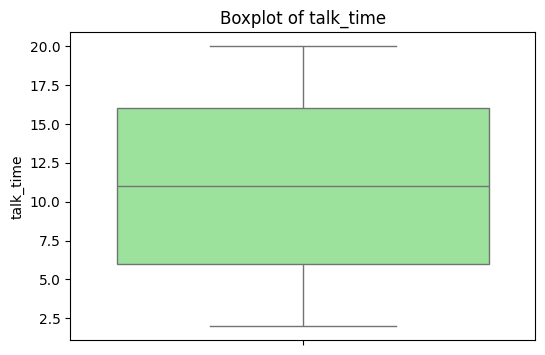

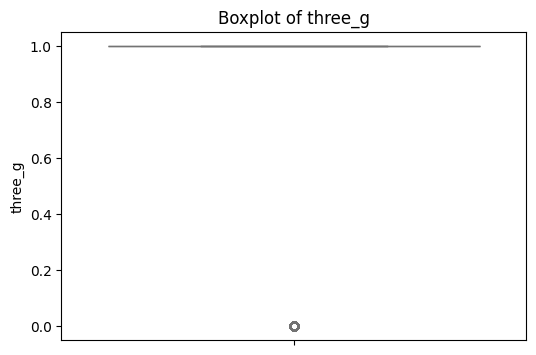

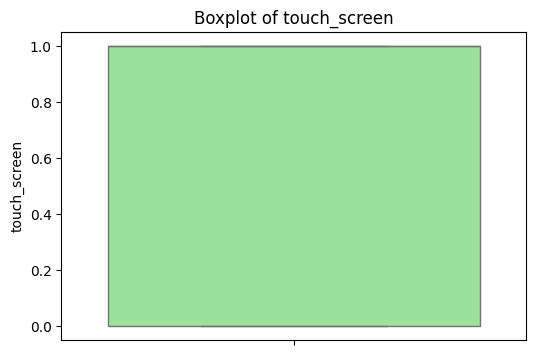

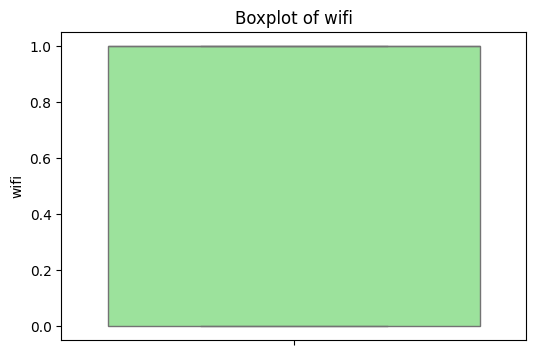

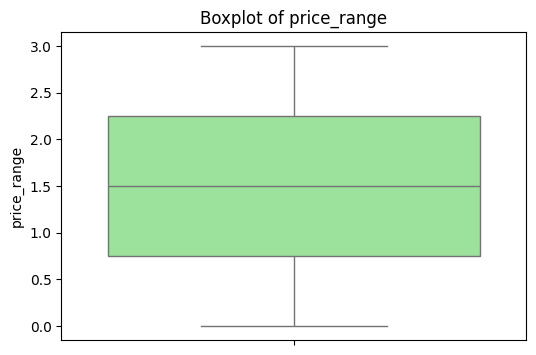

In [10]:
# Outliers detection using Visualization - Box plot
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting box plots for Numerical columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

Outliers are very few from above graphs and can be managed by ANN as:
1. They learn nonlinear relationships.
2. Training uses optimization (e.g., gradient descent), which can adapt to some noisy data.
3. With enough data, the network can learn to ignore rare extreme points.

SPLIT INTO FEATURES AND TARGETS

In [11]:
X = data.drop("price_range", axis=1)  # Features
y = data["price_range"]               # Target

In [12]:
#Display Features
X.head(2)

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,primary_camera,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0


All features are numerical values hence encoding not needed.

In [13]:
#Display Target
y.head(10)

,price_range
0,1
1,2
2,2
3,2
4,1
5,1
6,3
7,0
8,0
9,0


In [14]:
y.value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


Target has 4 class labels, hence performing Label-Binalizer

In [15]:
# One-hot encode labels using LabelBinarizer
from sklearn.preprocessing import LabelBinarizer    # For one-hot encoding target labels
lb = LabelBinarizer()      # Initialize the encoder
y = lb.fit_transform(y)    # Transform y into one-hot encoded vectors
y

array([[0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 1, 0],
       ...,
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 0, 1]])

SPLIT DATA INTO TEST DATA AND TRAIN DATA

In [16]:
from sklearn.model_selection import train_test_split   # For splitting dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train.shape

(1600, 20)

In [18]:
X_train.shape[1]  # number of features

20

In [33]:
X_test.shape

(400, 20)

In [20]:
y_train.shape

(1600, 4)

In [21]:
y_test.shape

(400, 4)

Standardize features

In [22]:
from sklearn.preprocessing import StandardScaler # For scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Building ANN Model using Hyperparameter tuning

In [23]:
# Hyperparameter tuning using keras-tuner
# install keras-tuner
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.6 MB/s eta 0:00:00


In [24]:
# Import Libraries
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report


In [25]:
#  Build Model Function for Tuner
def build_model(hp) :

    model = Sequential()

    # Tune number of neurons for Hidden layer 1
    model.add(Dense(
        units=hp.Int('units_1', min_value=8, max_value=64, step=8), # Will try values 8,16,24,32,40,48,56,64 and gives best
        activation='relu',          # ReLU - Helps the network learn nonlinear relationships and avoids vanishing gradient problems.
        input_shape=(20,)           # Specifies the number of input features
    ))

     # Tune number of neurons for Hidden layer 2
    model.add(Dense(
        units=hp.Int('units_2', min_value=8, max_value=64, step=8),
        activation='relu'
    ))

    # Tune dropout
    model.add(Dropout(
        rate=hp.Choice('dropout_rate', values=[0.2, 0.3, 0.4])   #If dropout = 0.3 → 30% of neurons(bubble) are randomly deactivated per batch.
    ))


    # Output Layer
    model.add(Dense(4, activation='softmax'))    # number of classes in the target variable


    # Tune learning rate
    model.compile(                              # compile the model - configure how the neural network will learn
        optimizer=tf.keras.optimizers.Adam(     # Optimizer controls how the model updates weights during training
            learning_rate=hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])
        ),
        loss='categorical_crossentropy',        # Loss function measures how far the predictions are from the true labels
        metrics=['accuracy']                    # Accuracy = percentage of correctly predicted samples
    )
    return model


In [26]:
#  Initialize Tuner
tuner = kt.RandomSearch(                  #randomly selects hyperparameter combinations instead of checking every possible combination.
    build_model,
    objective='val_accuracy',
    max_trials=10   #10 random combinations
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Search Best Hyperparameters
tuner.search(
    X_train, y_train,
    epochs=50,                # Number of times the model will iterate over the entire dataset
    validation_split=0.2,     # 20% of the training data will be used for validation
    batch_size=10,            # Number of samples per gradient update
    verbose=1
)

Trial 10 Complete [00h 00m 26s]
val_accuracy: 0.862500011920929

Best val_accuracy So Far: 0.9593750238418579
Total elapsed time: 00h 04m 28s


In [28]:
# Get Best Model
best_model = tuner.get_best_models(num_models=1)[0]  # Selects the first (best) model from the list.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
# Show Best Hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print("Units Layer 1:", best_hp.get('units_1'))
print("Units Layer 2:", best_hp.get('units_2'))
print("Dropout Rate:", best_hp.get('dropout_rate'))
print("Learning Rate:", best_hp.get('learning_rate'))



Best Hyperparameters:
Units Layer 1: 8
Units Layer 2: 40
Dropout Rate: 0.2
Learning Rate: 0.01


Evaluation of model

In [29]:
# Evaluate on Test Set
loss, accuracy = best_model.evaluate(X_test, y_test)
print("\nBest Model Test Accuracy:", accuracy)
print("\nBest Model Test loss:", loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9479 - loss: 0.0998  

Best Model Test Accuracy: 0.9474999904632568

Best Model Test loss: 0.10913495719432831


In [31]:
# Classification Report
y_pred = np.argmax(best_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       105
           1       0.94      0.97      0.95        91
           2       0.93      0.91      0.92        92
           3       0.94      0.96      0.95       112

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



This ANN model correctly predicts the price range of mobile phones about 95% of the time.

This ANN can help Bob to predict mobile price ranges from features like RAM, internal memory, battery power, etc.